In [ ]:
from helper_functions import *
import numpy as np
from SPM import *
from ICA_code import cumulant_tensors
from cICA_functions import *
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from cICA_alternative_tensor_decomps import *
import pandas as pd
plt.rcParams['text.usetex'] = True
plt.rcParams.update({'font.size': 14})

# Comparing SPM-HTD with other combinations of ICA or tensor decomposition algorithms combination

In [19]:
# generate synthetic data

num_samples = 1000

np.random.seed(1)

# Parameters for the first beta distribution
a1, b1 = 2, 5  # Shape parameters for Beta(2, 5)

# Parameters for the second beta distribution
a2, b2 = 5, 4  # Shape parameters for Beta(5, 4)


mixing_prob = 0.5

choices = np.random.rand(2*num_samples) < mixing_prob
beta_samples = np.where(
    choices,
    np.random.beta(a1, b1, 2*num_samples),  # Samples from Uniform(0, 1)
    np.random.uniform(a2, b2, 2*num_samples)  # Samples from Uniform(2, 3)
)


s_1 = 1.2*beta_samples[:num_samples]
s_2 = 1.2*beta_samples[num_samples:]
index_list = []
for i in range(num_samples):
    if s_1[i]<np.mean(s_1) and s_2[i]<np.mean(s_2):
        index_list.append(0)
    elif s_1[i]<np.mean(s_1) and s_2[i]>np.mean(s_2):
        index_list.append(1)
    elif s_1[i]>np.mean(s_1) and s_2[i]<np.mean(s_2):
        index_list.append(2)
    elif s_1[i]>np.mean(s_1) and s_2[i]>np.mean(s_2):
        index_list.append(3)
# Convert the list to a numpy array
index_array = np.array(index_list)


n = 5
A=np.random.randn(n-2,n-2)
A = A/np.linalg.norm(A,axis=0)

B = np.random.randn(2,n-2)
B = B/np.linalg.norm(B,axis=0)

mixing_matrix = np.eye(n)
mixing_matrix[:3,:3] = 0.9*A
mixing_matrix[3:5,:3] = 0.1*B
mixing_matrix = mixing_matrix/np.linalg.norm(mixing_matrix,axis=0)
uniform_dis_scale = np.array(range(5,5+n))
uniform_samples = np.random.rand(n-2,2*num_samples)

x = np.zeros((n,num_samples))
x[:3,:] = uniform_samples[:,:num_samples]

y = uniform_samples[:,num_samples:]
uniform_scale = np.array(range(5,5+n))
for i in range(n-2):
    x[i,:]=  x[i,:]*uniform_scale[i]
    y[i,:] = y[i,:]*uniform_scale[n-i-1]
    

x[3,:] = s_1
x[4,:] = s_2

X=(mixing_matrix@x).T
Y = (mixing_matrix[:,:-2]@ y).T

num_samples = 200
X_sub = X[:num_samples,:]
Y_sub = Y[:num_samples,:]
index_array_sub= index_array[:num_samples]
from sklearn.decomposition import PCA
pca_1 = PCA(n_components=2)
pca_2 = PCA(n_components=5)
X_pca = pca_2.fit_transform(X)
Y_pca = pca_1.fit_transform(Y)

Text(0.5, 1.0, 'SPM then SPM')

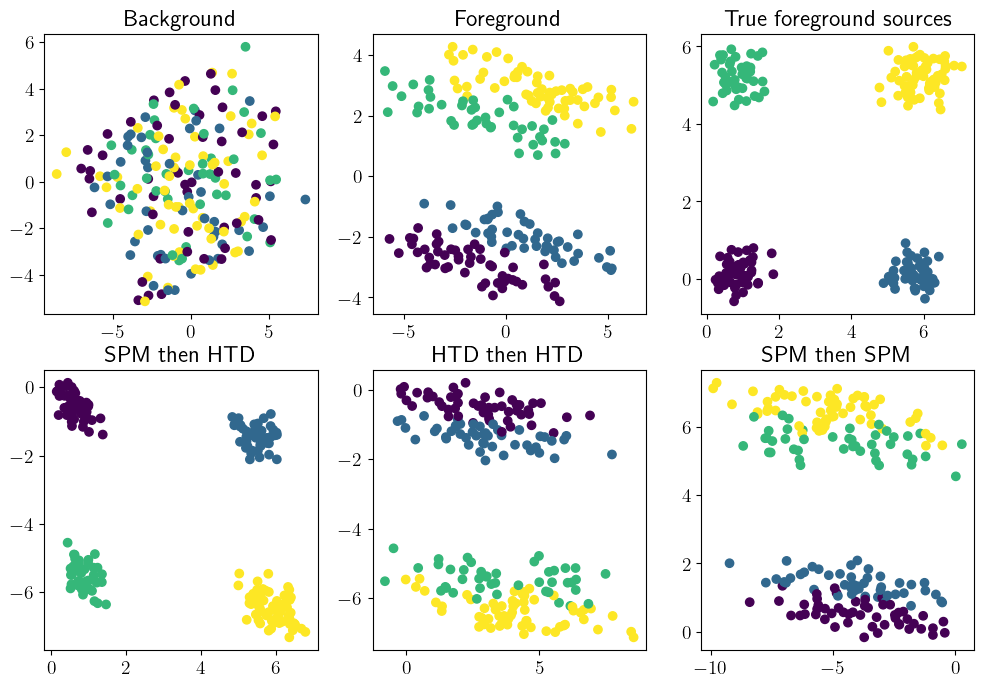

In [ ]:

fig, ax = plt.subplots(2, 3, figsize=(12, 8))

ax[0,0].scatter(Y_pca[:num_samples, 0], Y_pca[:num_samples, 1], c = index_array_sub)
ax[0, 1].scatter(X_pca[:num_samples, 0], X_pca[:num_samples, 1], c =  index_array_sub)
ax[0,2].scatter(X_sub@mixing_matrix[:,-1].T,X_sub@mixing_matrix[:,-2].T, c=index_array_sub)


k2_f,k4_f=cumulant_tensors(X_sub)
k2_b, k4_b=cumulant_tensors(Y_sub)
a_s_1,b_s_1,_  = recover_pattern_tensor_eigen(k4_b.copy(),k4_f.copy(),k2_f.copy(),k2_b.copy(),r=3,l=2)
ax[1,0].scatter(X_sub@(b_s_1[:,0].T),X_sub@(b_s_1[:,1].T),c = index_array_sub)

k2_f,k4_f=cumulant_tensors(X_sub)
k2_b, k4_b=cumulant_tensors(Y_sub)
a_s_2,b_s_2  = recover_pattern_HTDHTD(k4_b.copy(),k4_f.copy(),k2_f.copy(),k2_b.copy(),r=3,l=2)
ax[1,1].scatter(X_sub@(b_s_2[:,0].T),X_sub@(b_s_2[:,1].T),c = index_array_sub)

k2_f,k4_f=cumulant_tensors(X_sub)
k2_b, k4_b=cumulant_tensors(Y_sub)
a_s_3,b_s_3  = recover_pattern_SPM_SPM(k4_b.copy(),k4_f.copy(),k2_f.copy(),k2_b.copy(),r=3,l=2)
ax[1,2].scatter(X_sub@(b_s_3[:,0].T),X_sub@(b_s_3[:,1].T),c = index_array_sub)

ax[0,0].set_title('Background')
ax[0,1].set_title('Foreground')
ax[0,2].set_title('True foreground sources')
ax[1,0].set_title('SPM then HTD')
ax[1,1].set_title('HTD then HTD')
ax[1,2].set_title('SPM then SPM')


Number of iter: 12
Number of iter: 12


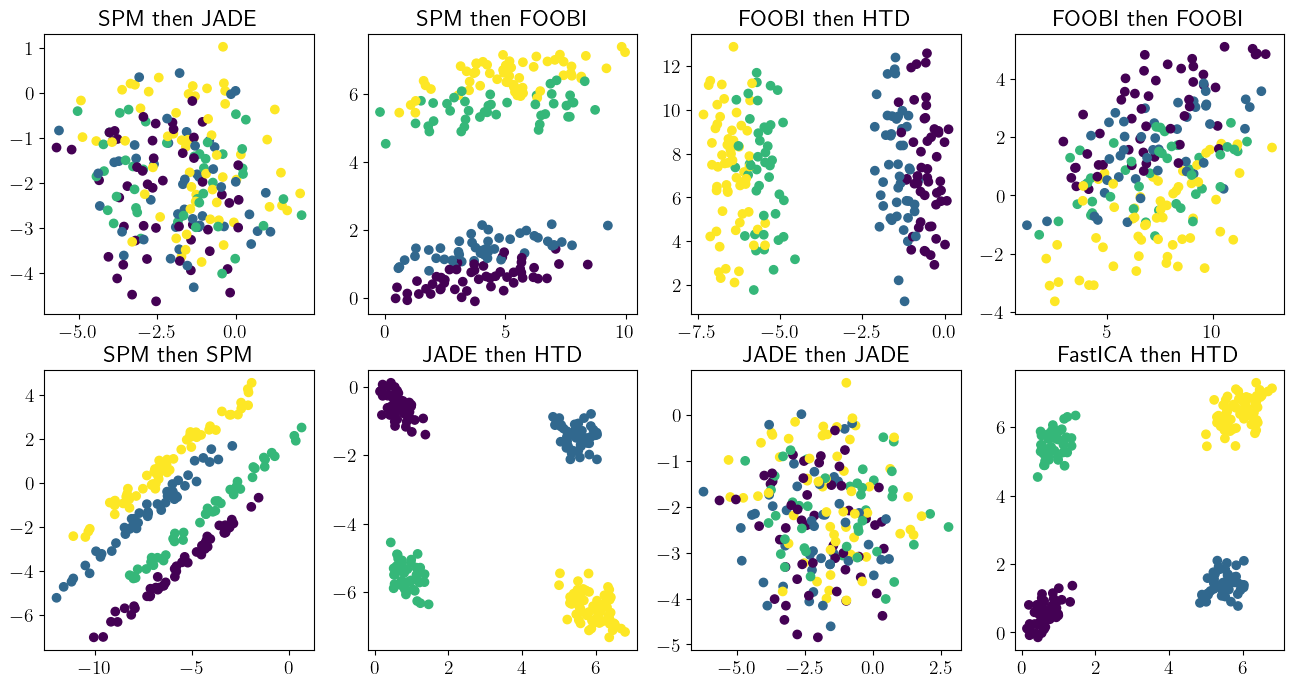

In [ ]:
np.random.seed()

fig, ax = plt.subplots(2, 4, figsize=(16, 8))

a_s_4,b_s_4  = recover_pattern_SPM_JADE(k4_b.copy(),k4_f.copy(),k2_f.copy(),k2_b.copy(),r=3,l=2)
ax[0,0].scatter(X_sub@(b_s_4[:,0].T),X_sub@(b_s_4[:,1].T),c = index_array_sub)

a_s_5,b_s_5  = recover_pattern_SPM_FOOBI(k4_b.copy(),k4_f.copy(),k2_f.copy(),k2_b.copy(),r=3,l=2)
ax[0,1].scatter(X_sub@(b_s_5[:,0].T),X_sub@(b_s_5[:,1].T),c = index_array_sub)

a_s_6,b_s_6 = recover_pattern_FOOBI_HTD(k4_b.copy(),k4_f.copy(),k2_f.copy(),k2_b.copy(),r=3,l=2)
ax[0,2].scatter(X_sub@(b_s_6[:,0].T),X_sub@(b_s_6[:,1].T),c = index_array_sub)

_,a_s_7,b_s_7 = recover_pattern_FOOBI_FOOBI(k4_b.copy(),k4_f.copy(),k2_f.copy(),k2_b.copy(),r=3,l=2)
ax[0,3].scatter(X_sub@(b_s_7[:,0].T),X_sub@(b_s_7[:,1].T),c = index_array_sub)

a_s_8,b_s_8 = recover_pattern_separate(k4_b.copy(),k4_f.copy(),k2_f.copy(),k2_b.copy(),r=3,l=2)
ax[1,0].scatter(X_sub@(b_s_8[:,0].T),X_sub@(b_s_8[:,1].T),c = index_array_sub)

a_s_9,b_s_9 = recover_pattern_JADE_HTD(Y_sub,k4_b.copy(),k4_f.copy(),k2_f.copy(),k2_b.copy(),r=3,l=2)
ax[1,1].scatter(X_sub@(b_s_9[:,0].T),X_sub@(b_s_9[:,1].T),c = index_array_sub)

a_s_10,b_s_10 = recover_pattern_JADE_JADE(Y_sub,k4_b.copy(),k4_f.copy(),k2_f.copy(),k2_b.copy(),r=3,l=2)
ax[1,2].scatter(X_sub@(b_s_10[:,0].T),X_sub@(b_s_10[:,1].T),c = index_array_sub)

a_s_11,b_s_11 = recover_pattern_FastICA_HTD(Y_sub,k4_b.copy(),k4_f.copy(),k2_f.copy(),k2_b.copy(),r=3,l=2)
ax[1,3].scatter(X_sub@(b_s_11[:,0].T),X_sub@(b_s_11[:,1].T),c = index_array_sub)

ax[0,0].set_title('SPM then JADE')
ax[0,1].set_title('SPM then FOOBI')
ax[0,2].set_title('FOOBI then HTD')
ax[0,3].set_title('FOOBI then FOOBI')
ax[1,0].set_title('SPM then SPM')
ax[1,1].set_title('JADE then HTD')
ax[1,2].set_title('JADE then JADE')
ax[1,3].set_title('FastICA then HTD')




In [ ]:
# generate synthetic data same approach as before

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

num_samples = 1000

np.random.seed(0)
# Parameters for the first beta distribution
a1, b1 = 2, 5  # Shape parameters for Beta(2, 5)

# Parameters for the second beta distribution
a2, b2 = 5, 4  # Shape parameters for Beta(5, 4)


mixing_prob = 0.5

choices = np.random.rand(2*num_samples) < mixing_prob
beta_samples = np.where(
    choices,
    np.random.beta(a1, b1, 2*num_samples),  # Samples from Uniform(0, 1)
    np.random.uniform(a2, b2, 2*num_samples)  # Samples from Uniform(2, 3)
)


s_1 = 1.5*beta_samples[:num_samples]
s_2 = 1.5*beta_samples[num_samples:]
index_list = []
for i in range(num_samples):
    if s_1[i]<np.mean(s_1) and s_2[i]<np.mean(s_2):
        index_list.append(0)
    elif s_1[i]<np.mean(s_1) and s_2[i]>np.mean(s_2):
        index_list.append(1)
    elif s_1[i]>np.mean(s_1) and s_2[i]<np.mean(s_2):
        index_list.append(2)
    elif s_1[i]>np.mean(s_1) and s_2[i]>np.mean(s_2):
        index_list.append(3)
# Convert the list to a numpy array
index_array = np.array(index_list)


n = 5
A=np.random.randn(n-2,n-2)
A = A/np.linalg.norm(A,axis=0)

B = np.random.randn(2,n-2)
B = B/np.linalg.norm(B,axis=0)

mixing_matrix = np.eye(n)
mixing_matrix[:3,:3] = 0.9*A
mixing_matrix[3:5,:3] = 0.1*B
mixing_matrix = mixing_matrix/np.linalg.norm(mixing_matrix,axis=0)
uniform_dis_scale = np.array(range(5,5+n))
uniform_samples = np.random.rand(n-2,2*num_samples)

x = np.zeros((n,num_samples))
x[:3,:] = uniform_samples[:,:num_samples]

y = uniform_samples[:,num_samples:]
uniform_scale = np.array(range(5,5+n))
for i in range(n-2):
    x[i,:]=  x[i,:]*uniform_scale[i]
    y[i,:] = y[i,:]*uniform_scale[n-i-1]
    

x[3,:] = s_1
x[4,:] = s_2

X=(mixing_matrix@x).T
Y = (mixing_matrix[:,:-2]@ y).T


In [ ]:
# take maximum, fix subset 

import random

np.random.seed()

# Evaluate silhouette scores for different methods
def silhouette_score_methods_max(total_num_samples,num_samples, X, Y, index_array):
    # Use only the first `num_samples` rows

    random.seed()
    np.random.seed()
    # Define methods and their corresponding recovery functions
    methods = {
        'SPM_HTD': recover_pattern_tensor_eigen,
        'HTD_HTD': recover_pattern_HTDHTD,
        'SPM_SPM': recover_pattern_SPM_SPM,
        'SPM_SPM_Seperate':recover_pattern_separate,
        'SPM_JADE': recover_pattern_SPM_JADE,
        'JADE_HTD': recover_pattern_JADE_HTD,
        'JADE_JADE': recover_pattern_JADE_JADE,
        'FOOBI_HTD': recover_pattern_FOOBI_HTD,
        'SPM_FOOBI': recover_pattern_SPM_FOOBI,
        'FOOBI_FOOBI': recover_pattern_FOOBI_FOOBI,
        'FastICA_HTD': recover_pattern_FastICA_HTD
    }

    num_repeat_1 = 20
    num_repeat_2 = 20
    average_sil_score_dict = {}
    for method_name, recovery_function in methods.items():
        average_sil_score_dict[method_name] = []
    average_sil_score_dict['source'] = []
    for _ in range(num_repeat_1):
        random_subset = random.sample(range(0, total_num_samples), num_samples)
        X_sub = X[random_subset, :]
        Y_sub = Y[random_subset, :]
        index_array_sub = index_array[random_subset]
        k2_f, k4_f = cumulant_tensors(X_sub)
        k2_b, k4_b = cumulant_tensors(Y_sub)

        # Loop through each method and compute silhouette scores three times
        # Initialize dictionary to store silhouette scores
        sil_score_dict = {}
        for method_name, recovery_function in methods.items():
            score_1 = -np.inf  # Initialize the maximum score
            # # Compute silhouette score for the source
            score_2 = silhouette_score(X_sub[:, [3, 4]], index_array_sub)

            for _ in range(num_repeat_2):  # Repeat n times
                # random_subset = random.sample(range(0, total_num_samples), num_samples)
                # X_sub = X[random_subset, :]
                # Y_sub = Y[random_subset, :]
                # index_array_sub = index_array[random_subset]
                

                # Recover patterns using the recovery function
                if method_name in ['FOOBI_FOOBI']:  # Special case with three outputs
                    _, _, b_s = recovery_function(k4_b.copy(), k4_f.copy(), k2_f.copy(), k2_b.copy(), r=3, l=2)
                elif method_name in ['JADE_HTD', 'JADE_JADE', 'FastICA_HTD']:  # Methods that use Y
                    _, b_s = recovery_function(Y.copy(), k4_b.copy(), k4_f.copy(), k2_f.copy(), k2_b.copy(), r=3, l=2)
                else:  # General case
                    if method_name == 'SPM_HTD':
                        a_s, b_s,_ = recovery_function(k4_b.copy(), k4_f.copy(), k2_f.copy(), k2_b.copy(), r=3, l=2)
                    else:
                        a_s, b_s = recovery_function(k4_b.copy(), k4_f.copy(), k2_f.copy(), k2_b.copy(), r=3, l=2)
                    
                # Compute silhouette scores
                score = silhouette_score(np.vstack((X_sub @ (b_s[:, 0].T), X_sub @ (b_s[:, 1].T))).T, index_array_sub)
                score_1 = max(score_1,score)
                # Early stopping if score is sufficiently high
                if score_1>0.75:
                     break
            # Store the average score for the method
            sil_score_dict[method_name] = score_1
            sil_score_dict['source'] = score_2
        for method_name, score in sil_score_dict.items():
            average_sil_score_dict[method_name].append(score)

    return average_sil_score_dict




sil_score_list = []
for num_samples in np.linspace(100,1000,40).astype(int):
    sil_score_list.append(silhouette_score_methods_max(1000,num_samples, X,Y,index_array))

df = pd.DataFrame(sil_score_list)
df['num_samples'] = np.linspace(100,1000,40).astype(int)

In [ ]:
for each_ele in sil_score_list:
    for key in each_ele.keys():
        each_ele[key] = np.mean(each_ele[key])

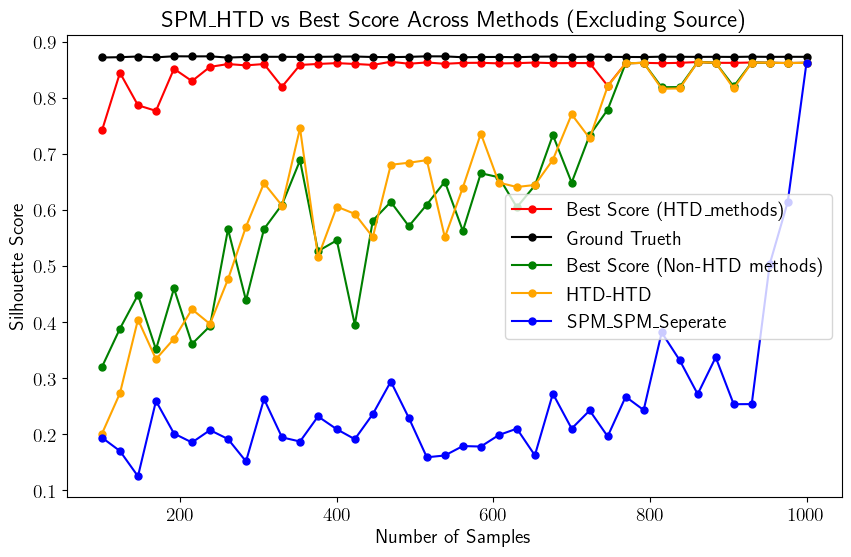

In [ ]:


import pandas as pd
import matplotlib.pyplot as plt


num_samples = df['num_samples']
# Extract the scores for SPM_HTD and the best score among all methods (excluding 'source')
spm_htd_scores = df['SPM_HTD']

best_scores = df.drop(columns=['num_samples', 'source']).max(axis=1)  # Exclude 'source'

non_htd_methods = [col for col in df.columns if not col.endswith('HTD') and col not in ['num_samples', 'source', 'SPM_SPM_Seperate']]
best_non_htd_scores = df[non_htd_methods].max(axis=1)


htd_methods = [col for col in df.columns if col.endswith('HTD') and col not in ['num_samples', 'source','SPM_HTD']]
best_htd_scores = df[htd_methods].max(axis=1)


spm_methods = [col for col in df.columns if col.startswith('SPM') and col not in ['num_samples', 'source']]
best_spm_scores = df[spm_methods].max(axis=1)


non_spm_methods = [col for col in df.columns if not col.startswith('SPM') and col not in ['num_samples', 'source']]
best_non_spm_scores = df[non_spm_methods].max(axis=1)


# Create the figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the scores
# ax.plot(num_samples, spm_htd_scores, label='SPM_HTD', color='orange', marker='o', markersize=5)
ax.plot(num_samples, best_htd_scores, label='Best Score (HTD_methods)', color='red', marker='o', markersize=5)
ax.plot(num_samples, df['source'], label='Ground Trueth', color='black', marker='o', markersize=5)
ax.plot(num_samples, best_non_htd_scores, label='Best Score (Non-HTD methods)', color='green', marker='o', markersize=5)
ax.plot(num_samples, df['HTD_HTD'], label='HTD-HTD', color='orange', marker='o', markersize=5)
ax.plot(num_samples, df['SPM_SPM_Seperate'], label='SPM_SPM_Seperate', color='blue', marker='o', markersize=5)

# Add labels, legend, and title
ax.set_xlabel('Number of Samples')
ax.set_ylabel('Silhouette Score')
ax.set_title('SPM_HTD vs Best Score Across Methods (Excluding Source)')
ax.legend()


In [190]:
import pandas as pd

# Exclude non-method columns like 'num_samples' and 'source'
method_columns = [col for col in df.columns if col not in ['num_samples', 'source']]

# Count the number of scores below 0.5 for each method
below_threshold_counts = (df[method_columns] < 0.6).sum()

# Create a table (DataFrame) to display the results
below_threshold_table = pd.DataFrame({
    'Method': below_threshold_counts.index,
    'Count Below 0.7': below_threshold_counts.values
})

# Print the table
print(below_threshold_table)

              Method  Count Below 0.7
0            SPM_HTD                5
1            HTD_HTD               13
2            SPM_SPM               17
3   SPM_SPM_Seperate               38
4           SPM_JADE               40
5           JADE_HTD               15
6          JADE_JADE               40
7          FOOBI_HTD                0
8          SPM_FOOBI               19
9        FOOBI_FOOBI               24
10       FastICA_HTD                0
